# JPSS VIIRS True Color — executed example

## Goal

Download an official Satpy Suomi NPP VIIRS demonstration granule, enter a
geographic domain in decimal longitude/latitude, create a True Color composite,
save it, and display the exact generated image inside this notebook.

The saved output below is produced by these cells, not by an external image.

## Setup

Install the notebook environment once from the repository root:

```bash
python -m pip install -r requirements-notebooks.txt
```

The first execution downloads the required I/M bands and terrain-corrected
geolocation files. Later executions reuse the local files.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
from PIL import Image as PillowImage
from satpy import Scene
from satpy.demo.viirs_sdr import get_viirs_sdr_20170128_1229

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.render_satellite import (
    crop_and_resample_scene,
    has_viirs_geolocation,
    save_dataset_with_lonlat_grid,
    validate_bbox,
)

## Steps

### 1. Enter the decimal domain

The order is `MIN_LON, MIN_LAT, MAX_LON, MAX_LAT`. All four values are written
as decimal degrees. This domain intersects the public demo swath.

In [2]:
DEMO_DATA_DIR = REPO_ROOT / "data" / "demo-viirs"
DEMO_CHANNELS = ("I01", "I02", "M03", "M04", "M05")
DOMAIN = (0.0, 35.0, 10.0, 38.0)
COMPOSITE = "true_color"
OUTPUT = REPO_ROOT / "output" / "notebook_viirs_demo_true_color.png"

validate_bbox(DOMAIN)

(0.0, 35.0, 10.0, 38.0)

### 2. Download one VIIRS granule and geolocation

The helper downloads one public Suomi NPP granule. Terrain-corrected `GITCO`
and `GMTCO` geolocation files are included for the requested I/M bands.

In [3]:
files = get_viirs_sdr_20170128_1229(
    base_dir=str(DEMO_DATA_DIR),
    channels=DEMO_CHANNELS,
    granules=(1,),
)
if not has_viirs_geolocation(files):
    raise FileNotFoundError("The matching VIIRS geolocation files are missing.")

print(f"VIIRS files: {len(files)}")
for filename in files:
    print(Path(filename).name)

VIIRS files: 7
GITCO_npp_d20170128_t1230144_e1231386_b27228_c20170128123806844060_cspp_dev.h5
GMTCO_npp_d20170128_t1230144_e1231386_b27228_c20170128123807370375_cspp_dev.h5
SVI01_npp_d20170128_t1230144_e1231386_b27228_c20170128123807637119_cspp_dev.h5
SVI02_npp_d20170128_t1230144_e1231386_b27228_c20170128123807711244_cspp_dev.h5
SVM03_npp_d20170128_t1230144_e1231386_b27228_c20170128123808110482_cspp_dev.h5
SVM04_npp_d20170128_t1230144_e1231386_b27228_c20170128123808144258_cspp_dev.h5
SVM05_npp_d20170128_t1230144_e1231386_b27228_c20170128123808174909_cspp_dev.h5


### 3. Load the True Color composite

In [4]:
scene = Scene(reader="viirs_sdr", filenames=files)
available = {str(name) for name in scene.available_composite_names()}
if COMPOSITE not in available:
    raise ValueError("The demo files cannot create a True Color composite.")

scene.load([COMPOSITE], generate=True)
print(f"Loaded composite: {COMPOSITE}")

The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


Loaded composite: true_color


### 4. Resample and save with a longitude/latitude grid

A regular WGS84 grid fills the VIIRS bow-tie deletion gaps and keeps the output
limited to the four decimal coordinates entered above. Longitude and latitude
labels are written into the saved PNG.

In [5]:
output_scene = crop_and_resample_scene(
    scene,
    domain=DOMAIN,
    resolution=0.01,
)
save_dataset_with_lonlat_grid(
    output_scene,
    COMPOSITE,
    OUTPUT,
    title="Suomi NPP VIIRS True Color — demo domain",
)

print(f"Image created: {OUTPUT.resolve()}")

Image created: /Users/rmsm1/Documents/Codex/2026-07-23/github-plugin-github-openai-curated-remote-5/GOES-VIIRS-Imagery-Guide/output/notebook_viirs_demo_true_color.png


### 5. Display the exact generated result

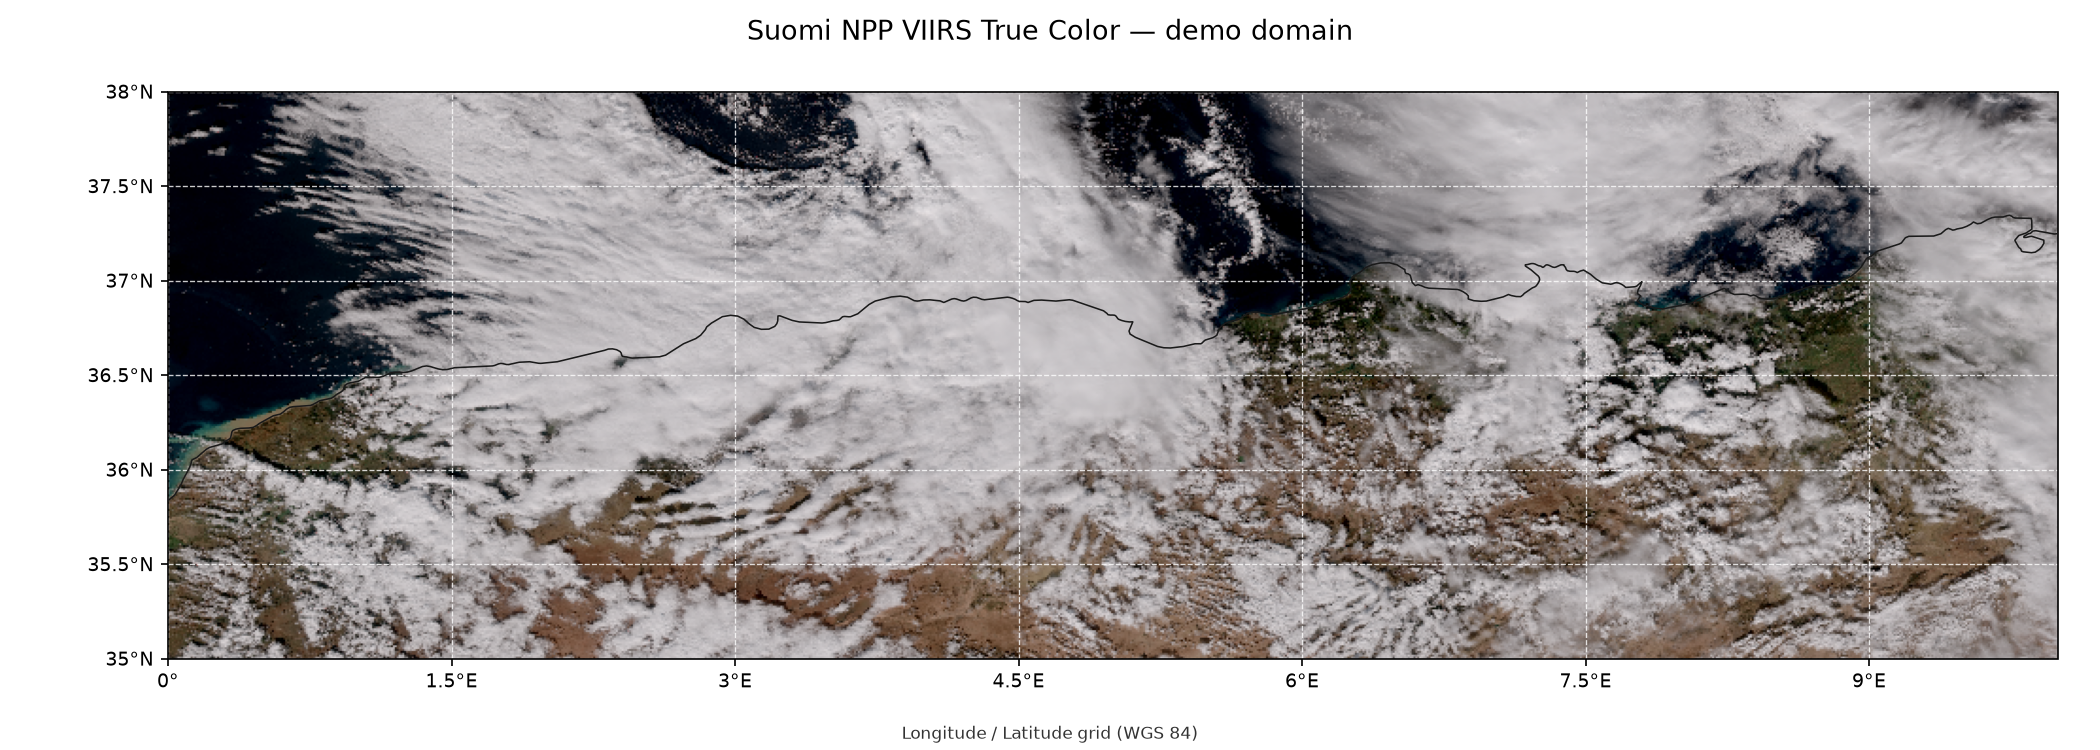

In [6]:
display(Image(filename=str(OUTPUT)))

## Checks

Confirm that the saved PNG exists and has nonzero dimensions.

In [7]:
if not OUTPUT.exists():
    raise FileNotFoundError(OUTPUT)

with PillowImage.open(OUTPUT) as image:
    print(f"PNG size: {image.width} x {image.height} pixels")
    assert image.width > 0 and image.height > 0

PNG size: 2100 x 750 pixels


## Next steps — use Shishaldin

The executed result above uses the official demo swath over another region.
For a VIIRS pass covering Shishaldin, replace `files` with matching spectral
and geolocation files from that pass, then enter:

```python
DOMAIN = (-166.0, 54.0, -162.0, 56.0)
```

Adjust every decimal value for the exact study area. The requested box must
intersect the downloaded swath.

Source: [Satpy VIIRS SDR demo documentation](https://satpy.readthedocs.io/en/stable/api/satpy.demo.html).